<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn import datasets
import pandas as pd

categories = [
  # 'alt.atheism',
  # 'comp.graphics',
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware',
  # 'comp.sys.mac.hardware',
  # 'comp.windows.x',
  # 'misc.forsale',
  # 'rec.autos',
  # 'rec.motorcycles',
  # 'rec.sport.baseball',
  # 'rec.sport.hockey',
  # 'sci.crypt',
  # 'sci.electronics',
  # 'sci.med',
  # 'sci.space',
  # 'soc.religion.christian',
  # 'talk.politics.guns',
  # 'talk.politics.mideast',
  # 'talk.politics.misc',
  # 'talk.religion.misc'
]

trn = datasets.fetch_20newsgroups(subset='train', categories=categories)


# Carga dos Dados

In [2]:

import pandas as pd

df = pd.DataFrame(trn.data, columns=['text'])
df['target'] = trn.target
df['target_names'] = df.target.apply(lambda x: trn.target_names[x])

df.head()


,text,target,target_names
0,From: rem@buitc.bu.edu (Robert Mee)\nSubject: ...,0,comp.os.ms-windows.misc
1,From: kushmer@bnlux1.bnl.gov (christopher kush...,1,comp.sys.ibm.pc.hardware
2,From: Richard.Muratti@f341.n632.z3.fidonet.org...,1,comp.sys.ibm.pc.hardware
3,From: wende@spk.hp.com (Mike Wende)\nSubject: ...,1,comp.sys.ibm.pc.hardware
4,From: leo@cae.wisc.edu (Leo Lim)\nSubject: FAS...,0,comp.os.ms-windows.misc


# Separação Treino / Teste

In [3]:
from sklearn.model_selection import train_test_split

# Split data into development and validation sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    df[['text']],
    df['target'],
    test_size=0.2,
    stratify=df['target'],
    random_state=42
)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_test.shape}")

Data splitting complete.
X_train shape: (944, 1)
X_val shape: (237, 1)
y_train shape: (944,)
y_val shape: (237,)


# Treinamento Pipelines

In [4]:

from sklearn.pipeline import Pipeline
from sklearn import tree, svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold


def train_model(clf, pipe, param_grid):

  pipe.steps.append(('classifier', clf))

  cvfold = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

  model = GridSearchCV(
      estimator=pipe,
      param_grid=param_grid,
      scoring=['precision', 'recall', 'accuracy', 'roc_auc'],
      cv=cvfold,
      refit = 'precision',
      return_train_score=True,
      n_jobs=-1
  ).fit(X_train['text'], y_train)

  print(model.best_params_)
  print(model.best_score_)

  return model




# Preprocessor
# TF-IDF
vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_features=500,
    stop_words='english'
)

# PCA
pca_model = PCA()

# # Classifier

# svm_clf = svm.SVC(
#     class_weight='balanced',
#     random_state=42,
#     probability=True
# )


# # Create a Pipeline that combines the preprocessor and the kNN classifier
# # This step needs to be re-executed after the preprocessor was updated.
# pipe_svm = Pipeline(steps=[('tf-idf', vectorizer),
#                            ('pca', pca_model),
#                            ('classifier', svm_clf)])
# pipe_dtc = Pipeline(steps=[('tf-idf', vectorizer),
#                            ('pca', pca_model),
#                            ('classifier', dtc_clf)])


params_dtc = {
  'pca__n_components': [100, 200],
  'classifier__max_depth': [3, 4, 5],
  'classifier__criterion': ['entropy'],
}
dtc_clf = tree.DecisionTreeClassifier(
    # criterion='entropy',
    # class_weight='balanced',
    random_state=42,
)

pipe = Pipeline(steps=[('tf-idf', vectorizer),
                       ('pca', pca_model)])

pipe_dtc = train_model(dtc_clf, pipe, params_dtc)

# SVM
params_svm = {
  'pca__n_components': [100, 200],
  'classifier__C': [0.01, 0.1, 1,],
  'classifier__kernel': ['rbf'],
}

svm_clf = svm.SVC(
    class_weight='balanced',
    random_state=42,
    probability=True
)


pipe = Pipeline(steps=[('tf-idf', vectorizer),
                       ('pca', pca_model)])
pipe_svm = train_model(svm_clf, pipe, params_svm)

{'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'pca__n_components': 200}
0.8350673970614986
{'classifier__C': 0.1, 'classifier__kernel': 'rbf', 'pca__n_components': 200}
0.9406502528453748


# Avaliação Modelo

## Árvore Decisão

              precision    recall  f1-score   support

           0       0.87      0.77      0.82       119
           1       0.79      0.88      0.84       118

    accuracy                           0.83       237
   macro avg       0.83      0.83      0.83       237
weighted avg       0.83      0.83      0.83       237

[[ 92  27]
 [ 14 104]]


/tmp/ipykernel_7579/2909658937.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(prob_test[y_test == c], bins=100)
/tmp/ipykernel_7579/2909658937.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(prob_test[y_test == c], bins=100)


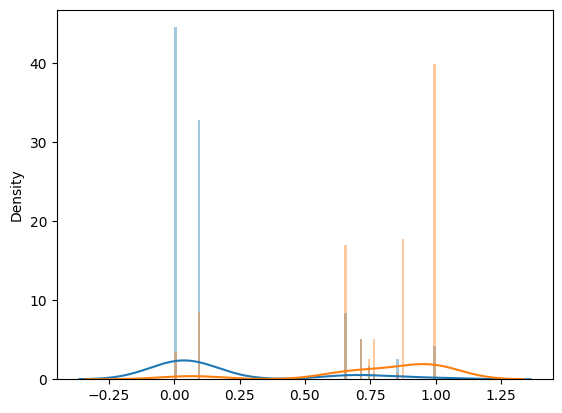

In [5]:
from sklearn import metrics

pred_test = pipe_dtc.predict(X_test['text'])
prob_test = pipe_dtc.predict_proba(X_test['text'])[:,1]

print(metrics.classification_report(y_test, pred_test))
print(metrics.confusion_matrix(y_test, pred_test))

import seaborn as sns

for c in [0,1]:
  sns.distplot(prob_test[y_test == c], bins=100)


## SVM

              precision    recall  f1-score   support

           0       0.83      0.96      0.89       119
           1       0.95      0.81      0.87       118

    accuracy                           0.88       237
   macro avg       0.89      0.88      0.88       237
weighted avg       0.89      0.88      0.88       237

[[114   5]
 [ 23  95]]


/tmp/ipykernel_7579/2689076002.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(prob_test[y_test == c], bins=100)
/tmp/ipykernel_7579/2689076002.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(prob_test[y_test == c], bins=100)


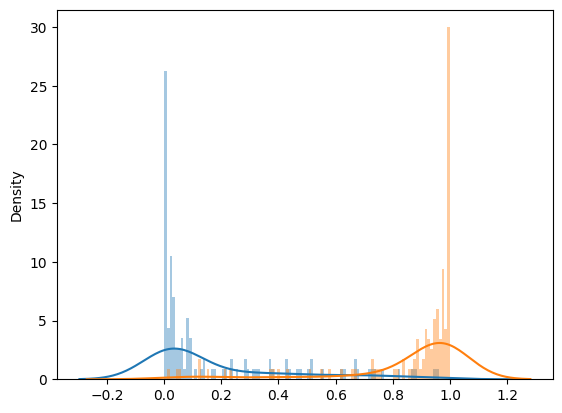

In [6]:
from sklearn import metrics

pred_test = pipe_svm.predict(X_test['text'])
prob_test = pipe_svm.predict_proba(X_test['text'])[:,1]

print(metrics.classification_report(y_test, pred_test))
print(metrics.confusion_matrix(y_test, pred_test))


import seaborn as sns

for c in [0,1]:
  sns.distplot(prob_test[y_test == c], bins=100)

## Comparação Modelos Curva ROC

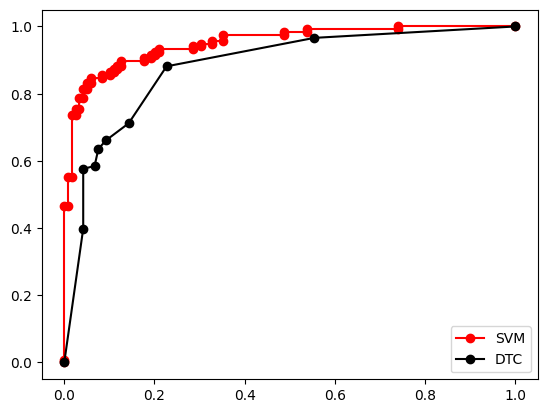

In [7]:
import matplotlib.pyplot as plt

prob_svm = pipe_svm.predict_proba(X_test['text'])[:,1]
prob_dtc = pipe_dtc.predict_proba(X_test['text'])[:,1]


fpr, tpr, thr = metrics.roc_curve(y_test, prob_svm)
plt.plot(fpr, tpr, '-or')


fpr, tpr, thr = metrics.roc_curve(y_test, prob_dtc)
plt.plot(fpr, tpr, '-ok')

plt.legend(['SVM', 'DTC'])
